In [1]:
import pandas as pd
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
DATA_FILE = "bysykkel_prophet_features_3h_weather_hois.csv"

# Tren på alt før dette tidspunktet
TRAIN_END = "2024-01-01"

In [3]:
print("Leser data …")
df = pd.read_csv(DATA_FILE, parse_dates=["ds"])

# Prophet krever kolonnene ds og y
df = df.sort_values("ds")

Leser data …


In [4]:
weather_cols = [
    "air_temperature",
    "wind_speed",
    "precipitation_amount"
]

df[weather_cols] = (
    df[weather_cols]
    .ffill()
    .bfill()
)

In [5]:
# --------------------------------------------------
# 2. TRAIN / TEST SPLIT (TIDSBASERT)
# --------------------------------------------------

train = df[df["ds"] < TRAIN_END].copy()
test  = df[df["ds"] >= TRAIN_END].copy()

print(f"Train: {train['ds'].min()} → {train['ds'].max()}")
print(f"Test : {test['ds'].min()} → {test['ds'].max()}")


Train: 2018-05-15 09:00:00 → 2023-11-29 21:00:00
Test : 2024-03-21 09:00:00 → 2025-11-19 09:00:00


In [6]:
regressors = [
    "air_temperature",
    "precipitation_amount",
    "wind_speed"
]

scaler = StandardScaler()

train[regressors] = scaler.fit_transform(train[regressors])
test[regressors]  = scaler.transform(test[regressors])

# --------------------------------------------------
# 4. DEFINER PROPHET-MODELL
# --------------------------------------------------

m = Prophet(
    growth="linear",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="multiplicative",  # viktig for etterspørsel
    changepoint_prior_scale=0.1          # moderat fleksibilitet
)

# Legg til regressorar
for r in regressors:
    m.add_regressor(r)

In [7]:
train.describe()

,ds,y,hour,weekday,is_weekend,weekofyear,month,year,is_winter,air_temperature,wind_speed,precipitation_amount
count,9484,9484.000000,9484.000000,9484.000000,9484.000000,9484.000000,9484.000000,9484.000000,9484.000000,9.484000e+03,9.484000e+03,9.484000e+03
mean,2021-03-27 11:24:31.657528,107.821489,11.998418,2.989983,0.283636,31.776360,7.741354,2020.633910,0.132539,-9.589780e-17,2.727094e-16,7.492015e-18
min,2018-05-15 09:00:00,1.000000,0.000000,0.000000,0.000000,13.000000,3.000000,2018.000000,0.000000,-3.650882e+00,-1.873155e+00,-2.908550e-01
25%,2019-08-21 20:15:00,30.000000,6.000000,1.000000,0.000000,24.000000,6.000000,2019.000000,0.000000,-6.629347e-01,-6.791642e-01,-2.908550e-01
50%,2021-06-05 19:30:00,77.000000,12.000000,3.000000,0.000000,32.000000,8.000000,2021.000000,0.000000,6.156752e-02,-2.015678e-01,-2.908550e-01
75%,2022-09-12 06:45:00,147.000000,18.000000,5.000000,1.000000,40.000000,10.000000,2022.000000,0.000000,6.561590e-01,5.148267e-01,-2.908550e-01
max,2023-11-29 21:00:00,910.000000,21.000000,6.000000,1.000000,51.000000,12.000000,2023.000000,1.000000,3.209405e+00,5.098425e+00,1.559117e+01
std,NaN,109.083624,5.995807,1.998630,0.450786,9.674501,2.208487,1.705297,0.339094,1.000053e+00,1.000053e+00,1.000053e+00


In [8]:
print("Trener Prophet-modell …")
m.fit(train[["ds", "y"] + regressors])

Trener Prophet-modell …


10:03:37 - cmdstanpy - INFO - Chain [1] start processing
10:03:52 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
future = test[["ds"] + regressors]
forecast = m.predict(future)

In [10]:
y_true = test["y"].values
y_pred = forecast["yhat"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("\n📊 Modellresultater")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")


📊 Modellresultater
MAE : 47.47
RMSE: 62.14


C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


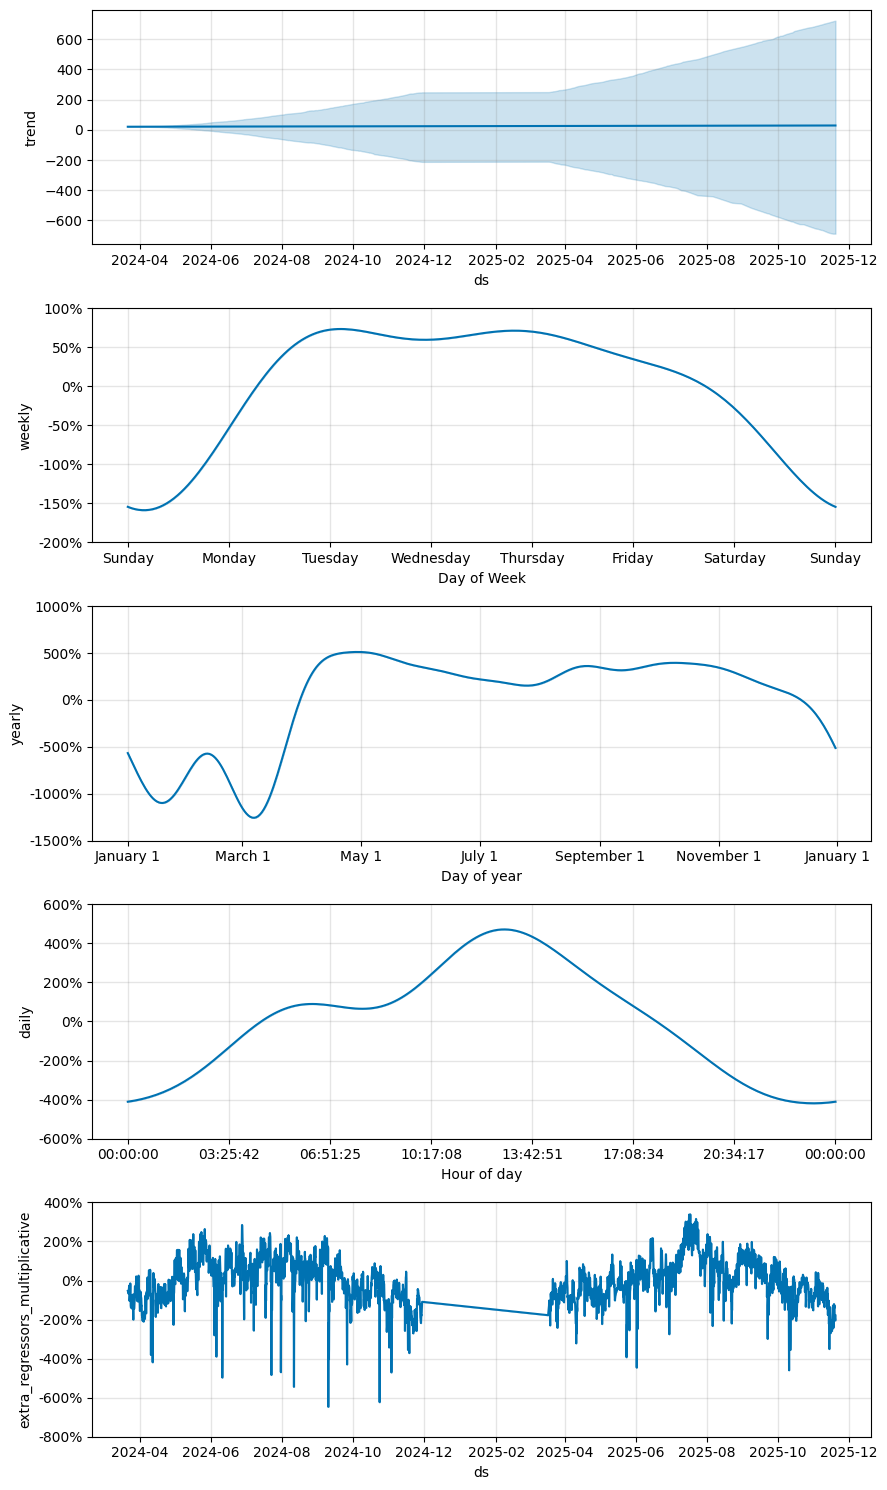

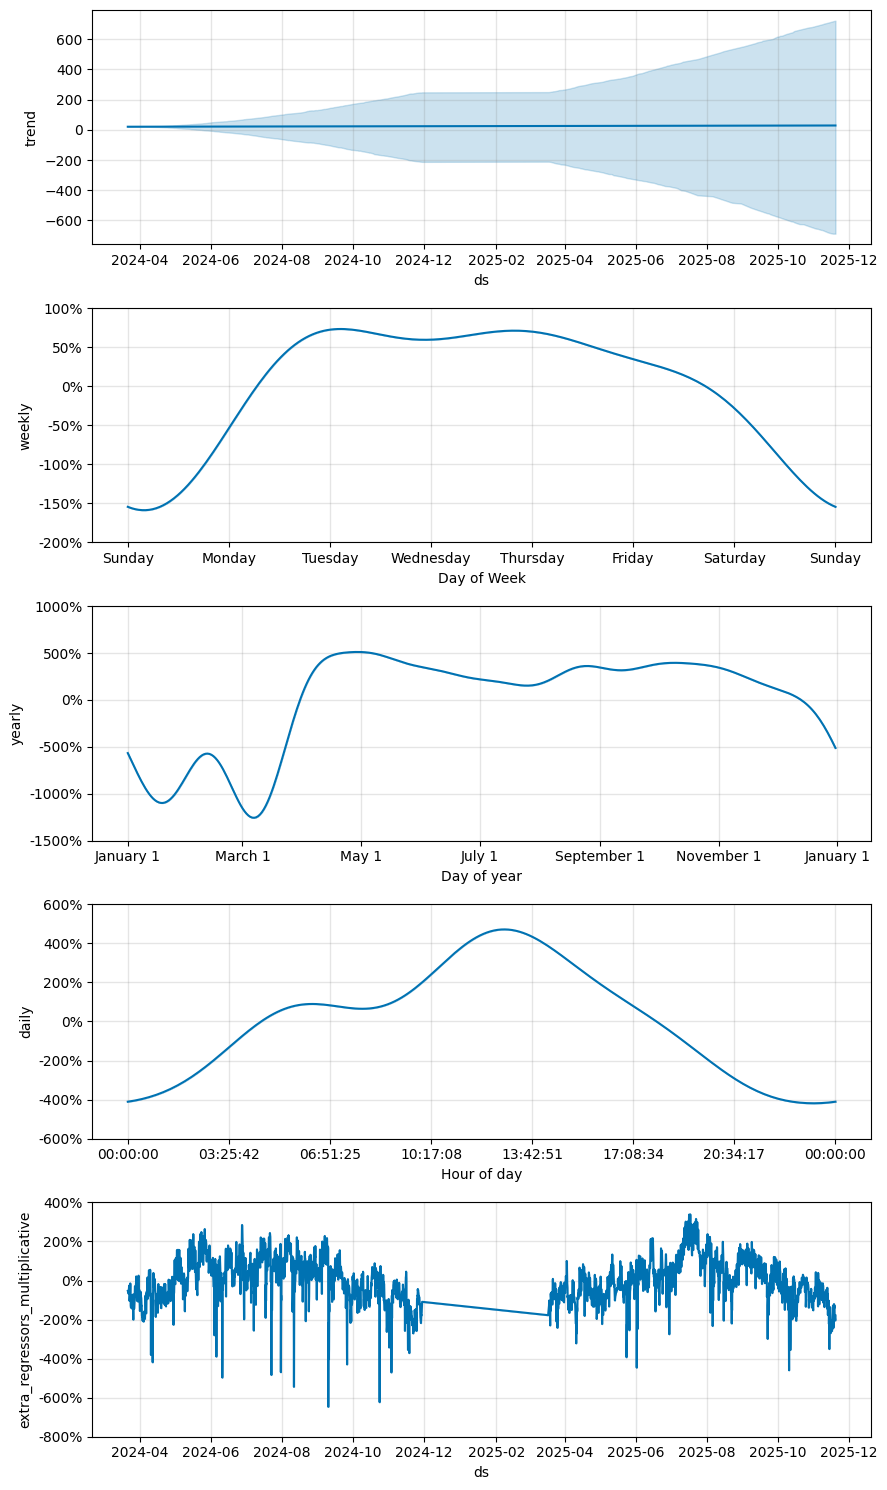

In [11]:
m.plot_components(forecast)
